In [5]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import rankdata
import itertools
import csv
import ast
import seaborn as sns
from scipy.stats import mannwhitneyu

In [6]:
def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

In [7]:
ne_path = '../data/fold_orders_csvs/fold_iters_pre_expansion.csv'  # original ne results with all pre-expansions

# DS average
a_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_archaea_recovered.csv'
b_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_bacteria_recovered.csv'
e_path = '../data/assets/xgroup2/DS_average/xgroup2DS_eukaryotes_recovered.csv'
ab_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBac_recovered.csv'
abe_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBacEuk_recovered.csv'

xgroup2ds_a = csv2dict(a_path)
print(len(xgroup2ds_a))
xgroup2ds_b = csv2dict(b_path)
print(len(xgroup2ds_b))
xgroup2ds_e = csv2dict(e_path)
print(len(xgroup2ds_e))
xgroup2ds_ab = csv2dict(ab_path)
print(len(xgroup2ds_ab))
xgroup2ds_abe = csv2dict(abe_path)
print(len(xgroup2ds_abe))

2230
2230
2230
2230
2230


In [8]:
# parse fold_iters
with open(ne_path, 'r') as file:
    lines = file.readlines()

data = []  # 10,000 * 397
labels = []  # 10,000
colnames = list(lines[0].strip().split(','))[3:-3]  # 397

lines = lines[1:]
for line in lines:
    if line[0] == ',':
        continue
    fo = line.split(',')[3:-3]
    pre = line.split(',')[-1].strip()  # pre-expansion labels
    data.append(fo)
    labels.append(pre)
np.array(data)
df = pd.DataFrame(data, index=labels)
df.columns = colnames

In [9]:
df.head()

,2002,1,2487,2006,2003,246,7525,218,2007,304,...,4025,4024,4046,3281,3843,3456,3579,4035,4054,4036
NONE,2,3,4,5,6,7,8,9,10,11,...,362,363,364,365,366,366,367,368,368,368
NONE,2,3,4,5,6,7,13,15,16,8,...,362,361,361,364,366,366,367,368,368,368
C00016,2,6,42,4,3,16,23,33,5,9,...,364,365,366,367,371,371,372,373,373,373
C00010,2,7,38,4,3,16,23,32,5,9,...,365,365,366,368,370,370,371,374,374,374
C00010,2,7,44,4,3,16,23,32,5,9,...,364,364,367,366,371,371,372,373,373,373


# use xgroup2ds to retrieve distribution scores

In [10]:
runs = {'NONE': [], 'C00016': [], 'C00010': [], 'C00019': [], 'Z00009': [], 'ALL': [], 'C00002': [], 'Z00035': [], 'Z00047': [], 'C00004': []}
for label, row in df.iterrows():  # 1000 runs * 10 labels
    iteration2xgroup = {}
    for x, iter_num in row.items():
        if iter_num not in iteration2xgroup:
            iteration2xgroup[str(iter_num)] = [x]
        else:
            iteration2xgroup[str(iter_num)].append(x)
    runs[label].append(iteration2xgroup)

In [11]:
len(runs['NONE'])

1000

# function to draw scatterplot

In [17]:
def my_func(label, xgroup2ds, title):
    runs_ds = []  # len=1,000*366ish; [{iter:[ds]}, {iter:[ds]}, ...]
    
    # for each run, for each iteration, map xgroups to dist scores
    for run in runs[label]: 
        iteration2ds = {}
        for iteration in run.keys():
            ds_list = []
            for xgroup in run[iteration]:
                ds_list.append(xgroup2ds[xgroup])
            iteration2ds[iteration] = ds_list
        runs_ds.append(iteration2ds)

    # within each iteration, take average of dist scores (some iteration injects 2+ folds)
    runs_ds_ave = []
    for run in runs_ds:
        iteration2ds_ave = {}
        for iteration in run.keys():
            iteration2ds_ave[iteration] = sum(run[iteration])/len(run[iteration])
        runs_ds_ave.append(iteration2ds_ave)
        
    # accumulate iteration2average_ds from 1000 runs
    iterations = {key: [] for key in runs_ds_ave[0]}
    for run in runs_ds_ave:
        for key in run.keys():
            if key in iterations.keys():
                iterations[key].append(run[key])
            else:
                iterations[key] = [run[key]]
                
    # take iteration-wise average of dist. scores across 1000 runs
    iterations_ave = {}
    for i in iterations.keys():
        iterations_ave[i] = sum(iterations[i])/len(iterations[i])
    
    y = list(iterations_ave.values())  # average dist score
    x = list(map(int, iterations_ave.keys()))  # iteration number
    
    print(title)
    print('average distribution score at iteration vs. iteration number')
    
    corr, p = spearmanr(x, y)
    print(f'spearman corr = {corr}, p_value = {p}')
    
    corr, p = pearsonr(x, y)
    print(f'pearson corr = {corr}, p_value = {p}')
    
    plt.scatter(x, y, marker='o', color='b', alpha = 0.1, zorder=2)
    plt.ylabel('average distribution score at iteration')
    plt.xlabel(f'iteration number ({label})')
    # plt.savefig(f'iterVSds_{label}.png')
    plt.show()

In [13]:
runs.keys()

dict_keys(['NONE', 'C00016', 'C00010', 'C00019', 'Z00009', 'ALL', 'C00002', 'Z00035', 'Z00047', 'C00004'])

arc + bac
average distribution score at iteration vs. iteration number
spearman corr = -0.861642023028738, p_value = 1.943825793690615e-110
pearson corr = -0.8613149801868598, p_value = 2.907006094163287e-110


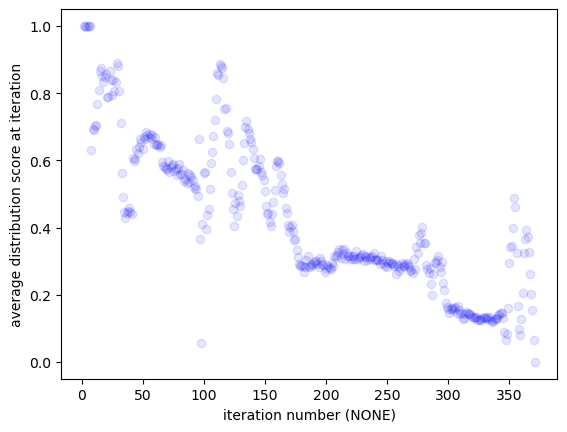

In [18]:
my_func('NONE', xgroup2ds_ab, 'arc + bac')
# my_func('C00002', xgroup2ds_ab, 'arc + bac')
# my_func('C00004', xgroup2ds_ab, 'arc + bac')
# my_func('C00010', xgroup2ds_ab, 'arc + bac')
# my_func('C00016', xgroup2ds_ab, 'arc + bac')
# my_func('C00019', xgroup2ds_ab, 'arc + bac')
# my_func('Z00009', xgroup2ds_ab, 'arc + bac')
# my_func('Z00035', xgroup2ds_ab, 'arc + bac')
# my_func('Z00047', xgroup2ds_ab, 'arc + bac')
# my_func('ALL', xgroup2ds_ab, 'arc + bac')

In [19]:
# show errorbar for y-axis

def my_func_range(label, xgroup2ds, title):
    runs_ds = []  # len=1,000*366ish; [{iter:[ds]}, {iter:[ds]}, ...]
    
    # for each run, map iteration to dist score
    for run in runs[label]: 
        iteration2ds = {}
        for iteration in run.keys():
            ds_list = []
            for xgroup in run[iteration]:
                ds_list.append(xgroup2ds[xgroup])
            iteration2ds[iteration] = ds_list
        runs_ds.append(iteration2ds)

    # take run-wise average of dist scores (some iteration injects 2+ folds)
    runs_ds_ave = []
    for run in runs_ds:
        iteration2ds_ave = {}
        for iteration in run.keys():
            iteration2ds_ave[iteration] = sum(run[iteration])/len(run[iteration])
        runs_ds_ave.append(iteration2ds_ave)
        
    # accumulate iteration2average_ds across 1000 runs
    iterations = {key: [] for key in runs_ds_ave[0]}
    for run in runs_ds_ave:
        for key in run.keys():
            if key in iterations.keys():
                iterations[key].append(run[key])
            else:
                iterations[key] = [run[key]]
                
    # take iteration-wise average across 1000 runs
    iterations_ave = {}
    for i in iterations.keys():
        iterations_ave[i] = sum(iterations[i])/len(iterations[i])  # mean
        
    iterations_std = {}
    for i in iterations.keys():
        iterations_std[i] = np.std(iterations[i])  # std.
        # iterations_std[i] = np.std(iterations[i]) / np.sqrt(np.size(iterations[i]))  # std. error
    
    y = list(iterations_ave.values())  # average dist score
    x = list(map(int, iterations_ave.keys()))  # iteration number
    y_err = list(iterations_std.values())  # variability 

    # Create a scatterplot with error bars
    plt.errorbar(x, y, yerr=y_err, fmt='o', alpha=0.2)
    corr, p = spearmanr(x, y)
    print(title)
    print(f'iteration number vs. average distribution score at iteration: corr = {corr}, p_value = {p}')
    plt.scatter(x, y, marker='o', color='b', alpha = 0.1, zorder=2)
    plt.ylabel('average distribution score at iteration')
    plt.xlabel(f'fold order')
    # plt.savefig(f'iterVSds_range_std_error.png', dpi=300, bbox_inches = 'tight')
    plt.show()

arc + bac
iteration number vs. average distribution score at iteration: corr = -0.861642023028738, p_value = 1.943825793690615e-110


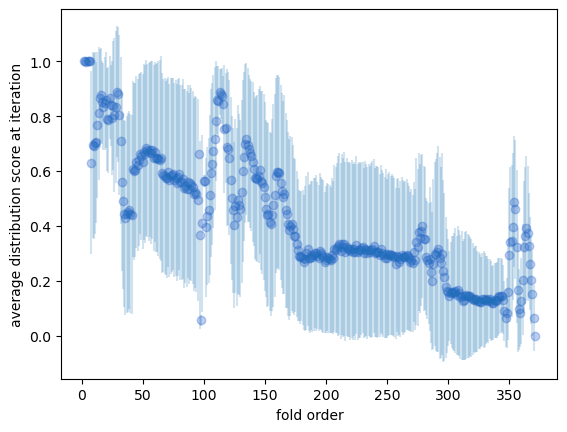

In [20]:
my_func_range('NONE', xgroup2ds_ab, 'arc + bac')
# my_func_range('C00002', xgroup2ds_ab, 'arc + bac')
# my_func_range('C00004', xgroup2ds_ab, 'arc + bac')
# my_func_range('C00010', xgroup2ds_ab, 'arc + bac')
# my_func_range('C00016', xgroup2ds_ab, 'arc + bac')
# my_func_range('C00019', xgroup2ds_ab, 'arc + bac')
# my_func_range('Z00009', xgroup2ds_ab, 'arc + bac')
# my_func_range('Z00035', xgroup2ds_ab, 'arc + bac')
# my_func_range('Z00047', xgroup2ds_ab, 'arc + bac')
# my_func_range('ALL', xgroup2ds_ab, 'arc + bac')

In [20]:
def my_func_line(label, xgroup2ds, title):
    runs_ds = []  # len=1,000*366ish; [{iter:[ds]}, {iter:[ds]}, ...]
    
    # for each run, map iteration to dist score
    for run in runs[label]: 
        iteration2ds = {}
        for iteration in run.keys():
            ds_list = []
            for xgroup in run[iteration]:
                ds_list.append(xgroup2ds[xgroup])
            iteration2ds[iteration] = ds_list
        runs_ds.append(iteration2ds)

    # take run-wise average of dist scores (some iteration injects 2+ folds)
    runs_ds_ave = []
    for run in runs_ds:
        iteration2ds_ave = {}
        for iteration in run.keys():
            iteration2ds_ave[iteration] = sum(run[iteration])/len(run[iteration])
        runs_ds_ave.append(iteration2ds_ave)
        
    # accumulate iteration2average_ds across 1000 runs
    iterations = {key: [] for key in runs_ds_ave[0]}
    for run in runs_ds_ave:
        for key in run.keys():
            if key in iterations.keys():
                iterations[key].append(run[key])
            else:
                iterations[key] = [run[key]]

#     print(iterations.keys())  # fold order [2-371]
    print(len(iterations.keys()))
    print([len(iterations[key]) for key in iterations.keys()])  # last 3 iternums don't always exist...
    
    
# Create 1000 line plots 
    plt.figure(figsize=(50, 10))
    colors = ['#0051ff', '#00ff04', 'black', '#ff8d00', '#ff1a00']
    
    for i in range(2, 3):
        plt.plot(list(iterations.keys())[:-3], [iterations[key][i] for key in list(iterations.keys())[:-3]] , color=colors[i], alpha = 0.5, zorder=2)

    plt.ylabel('average distribution score at iteration')
    plt.xlabel(f'fold order')
    plt.xticks([0, 98, 198, 298, 358])
    plt.xlim([2, 365])
    # plt.savefig(f'iterVSds_line_3.png', dpi=300, bbox_inches = 'tight')
    plt.show()

370
[1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000,

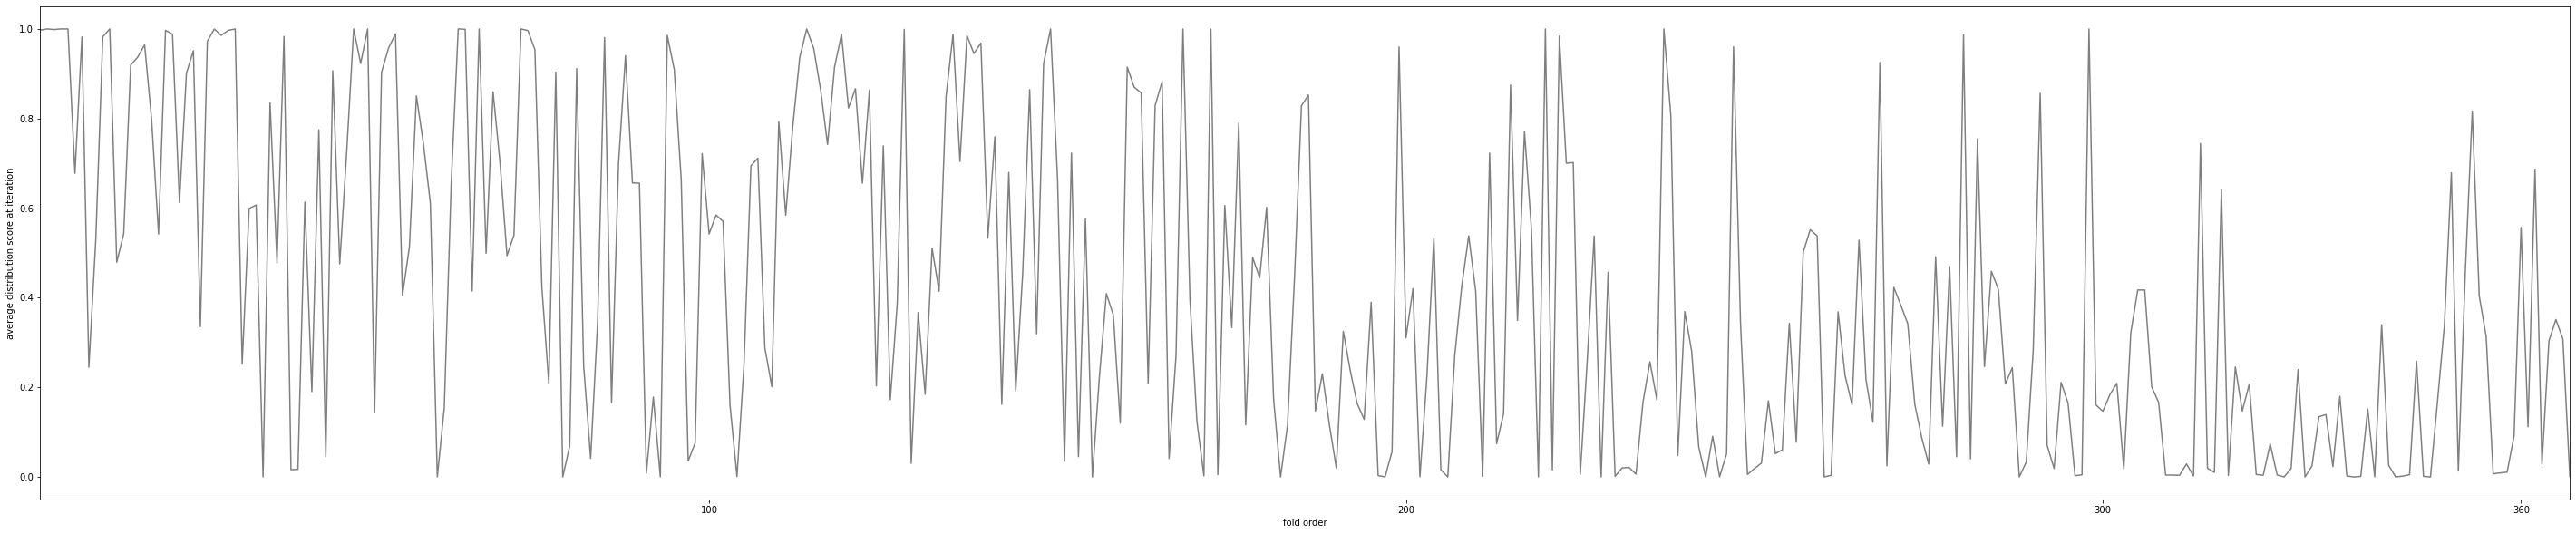

In [21]:
my_func_line('NONE', xgroup2ds_ab, 'arc + bac')

In [22]:
# show error bar for scatterplot WITH THE SAME #FOLDITER

def my_func_range_same_folditer(label, xgroup2ds, title, num_folditer):
    runs_ds = []  # len=1,000*370ish; [{iter:[ds]}, {iter:[ds, ds]}, ...]
    # map xgroup to dist score
    for run in runs[label]: 
        iteration2ds = {}
        for iteration in run.keys():
            ds_list = []
            for xgroup in run[iteration]:
                ds_list.append(xgroup2ds[xgroup])
            iteration2ds[iteration] = ds_list
        runs_ds.append(iteration2ds)

    # sometimes, 2-3 folds are injected in the same iteration
    # take iteration-wise average of dist scores {iter:[ds, ds]} => {iter:[ds_average]}
    runs_ds_ave = []
    for run in runs_ds:
        iteration2ds_ave = {}
        for iteration in run.keys():
            iteration2ds_ave[iteration] = sum(run[iteration])/len(run[iteration])
        runs_ds_ave.append(iteration2ds_ave)
        
    # accumulate iteration2average_ds across RUNS WITH THE SAME #FOLDITER
    runs_ds_ave_folditer = []
    for run in runs_ds_ave:
        if len(run.keys()) == num_folditer:
            runs_ds_ave_folditer.append(run)
    print(f'len(runs_ds_ave_folditer)={len(runs_ds_ave_folditer)}')
    
    iterations = {key: [] for key in runs_ds_ave_folditer[0]}
    for run in runs_ds_ave_folditer:
        for key in run.keys():
            if key in iterations.keys():
                iterations[key].append(run[key])
            else:
                iterations[key] = [run[key]]
                
    # take iteration-wise average across RUNS WITH THE SAME #FOLDITER
    iterations_ave = {}
    for i in iterations.keys():
        iterations_ave[i] = sum(iterations[i])/len(iterations[i])  # mean
        
    iterations_std = {}
    for i in iterations.keys():
        iterations_std[i] = np.std(iterations[i])  # std.
    
    y = list(iterations_ave.values())  # average dist score
    x = list(map(int, iterations_ave.keys()))  # iteration number
    y_err = list(iterations_std.values())  # variability

    # Create a scatterplot with error bars
    plt.errorbar(x, y, yerr=y_err, fmt='o', alpha=0.2)
    corr, p = spearmanr(x, y)
    print(title)
    print(f'iteration number vs. average distribution score at iteration: corr = {corr}, p_value = {p}')
    plt.scatter(x, y, marker='o', color='b', alpha = 0.1, zorder=2)
    plt.ylabel('average distribution score at iteration')
    plt.xlabel(f'fold order ({num_folditer})')
    # plt.savefig(f'iterVSds_range_std_{num_folditer}.png', dpi=300, bbox_inches = 'tight')
    plt.show()

len(runs_ds_ave_folditer)=100
arc + bac
iteration number vs. average distribution score at iteration: corr = -0.8327177186683737, p_value = 1.667561216020597e-96


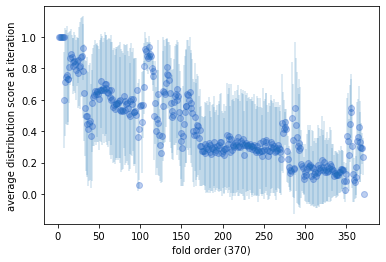

In [23]:
my_func_range_same_folditer('NONE', xgroup2ds_ab, 'arc + bac', 370)

# check average fold_order given xgroup

In [24]:
def x2aveFO(xgroup, label):
    fo_list = []
    for run in runs[label]: 
        for iteration in run.keys():          
            for x in run[iteration]:
                if x == xgroup:
                    fo_list.append(int(iteration))
    return [sum(fo_list) / len(fo_list), np.std(fo_list)]

In [25]:
x2aveFO('2003', 'NONE')

[6.511, 0.4998789853554558]

In [26]:
x2aveFO('3997', 'NONE')

[304.303, 5.128273686144296]

In [27]:
x2aveFO('3997', 'ALL')

[305.351, 20.484428207787495]

In [31]:
x2foMeanStdNONE = {}
for x in xgroup_keys:
    x2foMeanStdNONE[x] = x2aveFO(x, 'NONE')

In [32]:
# dict2csv(x2foMeanStdNONE, 'x2foMeanStdNONE.csv')

In [28]:
# let's only take the mean, and save them as csv
x2foAveNONE = {}
for x in xgroup_keys:
    x2foAveNONE[x] = x2aveFO(x, 'NONE')[0]

x2foAveALL = {}
for x in xgroup_keys:
    x2foAveALL[x] = x2aveFO(x, 'ALL')[0]
    
# dict2csv(x2foAveNONE, 'x2foAveNONE.csv')
# dict2csv(x2foAveALL, 'x2foAveALL.csv')

In [29]:
# keep this for analysis of mean, std
x2aveFO('602', 'NONE'), x2aveFO('4952', 'NONE'), x2aveFO('4953', 'NONE')

([106.619, 2.946156648924154],
 [106.619, 2.946156648924154],
 [107.619, 2.946156648924154])

# annotate group1 folds

In [ ]:
first10 = {'325', '2002', '218', '206', '4953', '2003', '2007', '602', '2005', '4952'}
group1 = {'3997', '1', '4011', '253', '7574', '875', '206', '3016', '328', '2486', '212', '148', '2002', '325', '4952', '218', '184', '7577', '2005', '2007', '4953', '7501', '7584', '7579', '297', '2492', '7523', '101', '141', '7544', '109', '2003', '2004', '602', '330', '304', '327'}

In [ ]:
for x in group1:
    print(x, xgroup2ds_ab[x], x2aveFO(x, 'NONE'))

In [ ]:
group1_ds = []
group1_fo = []
for x in group1 - first10:
    group1_ds.append(xgroup2ds_ab[x])
    group1_fo.append(x2foAveNONE[x])
    
first10_ds = []
first10_fo = []
for x in first10:
    first10_ds.append(xgroup2ds_ab[x])
    first10_fo.append(x2foAveNONE[x])

In [ ]:
# annotate group1

def my_func_red(label, xgroup2ds, title):
    runs_ds = []  # len=1,000*366ish; [{iter:[ds]}, {iter:[ds]}, ...]
    
    # for each run, map iteration to dist score
    for run in runs[label]: 
        iteration2ds = {}
        for iteration in run.keys():
            ds_list = []
            for xgroup in run[iteration]:
                ds_list.append(xgroup2ds[xgroup])
            iteration2ds[iteration] = ds_list
        runs_ds.append(iteration2ds)

    # take run-wise average of dist scores (some iteration injects 2+ folds)
    runs_ds_ave = []
    for run in runs_ds:
        iteration2ds_ave = {}
        for iteration in run.keys():
            iteration2ds_ave[iteration] = sum(run[iteration])/len(run[iteration])
        runs_ds_ave.append(iteration2ds_ave)
        
    # accumulate iteration2average_ds across 1000 runs
    iterations = {key: [] for key in runs_ds_ave[0]}
    for run in runs_ds_ave:
        for key in run.keys():
            if key in iterations.keys():
                iterations[key].append(run[key])
            else:
                iterations[key] = [run[key]]
                
    # take iteration-wise average across 1000 runs
    iterations_ave = {}
    for i in iterations.keys():
        iterations_ave[i] = sum(iterations[i])/len(iterations[i])  # mean
        
    iterations_std = {}
    for i in iterations.keys():
        iterations_std[i] = np.std(iterations[i])  # std.
    
    y = list(iterations_ave.values())  # average dist score
    x = list(map(int, iterations_ave.keys()))  # iteration number
    y_err = list(iterations_std.values())  # variability (standard deviation in this case)
    
    # blue = group1
    x_blue = group1_fo
    y_blue = group1_ds
    
    # gray = first10
    x_gray = first10_fo
    y_gray = first10_ds

    # Create a scatterplot with error bars
    plt.errorbar(x, y, yerr=y_err, fmt='o', alpha=0.2, color='red')
    corr, p = spearmanr(x, y)
    print(title)
    print(f'iteration number vs. average distribution score at iteration: corr = {corr}, p_value = {p}')
    plt.scatter(x, y, marker='o', color='red', alpha = 0.1, zorder=2)
    plt.scatter(x_blue, y_blue, marker='o', color='blue', alpha = 0.5, zorder=2)
    plt.scatter(x_gray, y_gray, marker='o', color='gray', alpha = 1, zorder=2)
    
    plt.ylabel('average distribution score at iteration')
    plt.xlabel(f'iteration number ({label})')
    # plt.savefig(f'iterVSds_{label}_range.png')
    plt.show()

In [ ]:
my_func_red('NONE', xgroup2ds_ab, 'arc + bac')

In [ ]:
my_func_red('NONE', xgroup2ds_ab, 'arc + bac')
my_func_red('NONE', xgroup2ds_e, 'euk')

In [ ]:
for x in first10:
    print(x, xgroup2ds_ab[x], x2aveFO(x, 'NONE'))

# check some folds

In [ ]:
label = 'ALL'
title = 'arc + bac'

runs_ds = []  # len=1,000*366ish; [{iter:[ds]}, {iter:[ds]}, ...]

# for each run, map iteration to dist score
for run in runs[label]: 
    iteration2ds = {}
    for iteration in run.keys():
        ds_list = []
        for xgroup in run[iteration]:
            ds_list.append(xgroup2ds_ab[xgroup])
        iteration2ds[iteration] = ds_list
    runs_ds.append(iteration2ds)

# take run-wise average of dist scores (some iteration injects 2+ folds)
runs_ds_ave = []
for run in runs_ds:
    iteration2ds_ave = {}
    for iteration in run.keys():
        iteration2ds_ave[iteration] = sum(run[iteration])/len(run[iteration])
    runs_ds_ave.append(iteration2ds_ave)

# accumulate iteration2average_ds across 1000 runs
iterations = {key: [] for key in runs_ds_ave[0]}
for run in runs_ds_ave:
    for key in run.keys():
        if key in iterations.keys():
            iterations[key].append(run[key])
        else:
            iterations[key] = [run[key]]

# take iteration-wise average across 1000 runs
iterations_ave = {}
for i in iterations.keys():
    iterations_ave[i] = sum(iterations[i])/len(iterations[i])  # mean

In [ ]:
for key, value in iterations_ave.items():
    print(key, value)

## dip at iter# = 98 (NONE)

In [ ]:
iter98 = []
for run in runs['NONE']:
    iter98.append(run['98'])
iter98

In [ ]:
x_set = set()
for injection in iter98:
    for x in injection:
        x_set.add(x)
print(x_set)

In [ ]:
# X108 |ds_a/b/e= 0.08 0.07 1.0 |fo=98.5 |ns=4294 |#rxn=59 |group2 |indep |Xname=EF-hand
# X4178 |ds_a/b/e= 0.02 0.12 0.92 |fo=97.5 |ns=4315 |#rxn=21 |group2 |aux |Xname=N/A
# X355 |ds_a/b/e= 0.0 0.0 0.38 |fo=97.5 |ns=4315 |#rxn=19 |group2 |aux |Xname=N/A

## dips at bottom left (ALL)

In [ ]:
bl = []
for iterNum, aveDS in iterations_ave.items():
    if aveDS < 0.5 and int(iterNum) < 80:
        print(iterNum, aveDS)
        bl.append(iterNum)

In [ ]:
for iterNum in bl:
    print(iterNum)
    for run in runs['ALL']:
        print(run[iterNum])
# note that it's always a single-fold injection

In [ ]:
bottomLeft = {'76': [],
 '25': [],
 '7': [],
 '77': [],
 '39': [],
 '30': [],
 '75': [],
 '62': []}

for iterNum in bl:
    for run in runs['ALL']:
        bottomLeft[iterNum].append(run[iterNum][0])

for key in bottomLeft.keys():
    bottomLeft[key] = set(bottomLeft[key])
bottomLeft

In [ ]:
x_set2 = set()
for key in bottomLeft.keys():
    for x in bottomLeft[key]:
        x_set2.add(x)

In [ ]:
x_set2

# checking why runs have different total(folditer) sizes

In [ ]:
['144', '3374']

In [ ]:
print(len(runs['NONE'][2].keys()))
print(len(runs['NONE'][0].keys()))
print(len(runs['NONE'][5].keys()))
print(len(runs['NONE'][4].keys()))
print(len(runs['NONE'][15].keys()))

In [ ]:
multiple366 = {}
count = 0
for key, values in runs['NONE'][2].items():
    if len(values) > 1:
        print(f"{key}: {values},")
        multiple366[key] = values
        count += 1
print(count)

In [ ]:
multiple367 = {}
count = 0
for key, values in runs['NONE'][0].items():
    if len(values) > 1:
        print(f"{key}: {values},")
        multiple367[key] = values
        count += 1
print(count)

In [ ]:
multiple368 = {}
count = 0
for key, values in runs['NONE'][5].items():
    if len(values) > 1:
        print(f"{key}: {values},")
        multiple368[key] = values
        count += 1
print(count)

# 102: ['7586', '4044']

In [ ]:
multiple369 = {}
count = 0
for key, values in runs['NONE'][4].items():
    if len(values) > 1:
        print(f"{key}: {values},")
        count += 1
        multiple369[key] = values
print(count)

# 102 ['4019', '223']

In [ ]:
multiple370 = {}
count = 0
for key, values in runs['NONE'][15].items():
    if len(values) > 1:
        print(f"{key}: {values},")
        count += 1
        multiple370[key] = values
print(count)

In [ ]:
multiples = {}
dicts = [multiple366, multiple367, multiple368, multiple369, multiple370]
for d in dicts:
    for value in d.values():
        if frozenset(value) not in multiples.keys():
            multiples[frozenset(value)] = 1
        else:
            multiples[frozenset(value)] += 1

In [ ]:
multiples